In [18]:
import tensorflow as tf
from datasets import load_dataset
import gc
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import psutil, os
import keras
from keras import layers, Model      


print("TF version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

vm = psutil.virtual_memory()

print(f"Total RAM (WSL sees):     {vm.total / 1024**3:.1f} GB")
print(f"Available right now:      {vm.available / 1024**3:.1f} GB")
print(f"Currently used (all):     {vm.used / 1024**3:.1f} GB")
print(f"Jupyter process itself:   {psutil.Process().memory_info().rss / 1024**3:.2f} GB")
print(f"\nJupyter can grow up to:  ~{vm.available / 1024**3:.1f} GB more before OOM")


TF version: 2.21.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Total RAM (WSL sees):     25.4 GB
Available right now:      12.5 GB
Currently used (all):     12.9 GB
Jupyter process itself:   11.24 GB

Jupyter can grow up to:  ~12.5 GB more before OOM


In [ ]:

ds = load_dataset('reczoo/Criteo_x1')
df = ds['train'].to_pandas().sample(n=30_000_000, random_state=42)
del ds
gc.collect()

print(df.shape)          # (500000, 40)
print(df.head())
print(df['label'].value_counts(normalize=True))  # Check class imbalance


Repo card metadata block was not found. Setting CardData to empty.


Loading dataset shards:   0%|          | 0/30 [00:00<?, ?it/s]

(16000000, 40)
          label    I1        I2    I3    I4        I5     I6    I7    I8  \
38281499      0  0.00  0.233831  0.07  0.00  0.538062  0.540  0.02  0.00   
17867133      0  0.10  0.009950  0.00  0.06  0.004812  0.012  0.05  0.30   
42230578      1  0.00  0.003317  0.00  0.00  0.060047  0.104  0.06  0.08   
41645893      0  0.15  0.006633  1.00  0.32  0.001094  0.196  0.03  0.72   
19631550      0  0.05  0.003317  0.47  0.78  0.018922  0.088  0.04  0.98   

             I9  ...      C17      C18      C19      C20      C21      C22  \
38281499  0.270  ...  1528982  1528995  1533924  1536018  1536024  1934144   
17867133  0.050  ...  1528982  1530066  1533924  1536018  1539920  1934144   
42230578  0.164  ...  1528982  1528998  1534144  1536019  1536022  1934144   
41645893  0.088  ...  1528989  1529009  1533925  1536020  1536022  1934144   
19631550  0.466  ...  1528982  1529038  1533933  1536020  1536022  1934146   

              C23      C24      C25      C26  
38281499  19

In [4]:
cat_cols = [col for col in df.columns if col.startswith('C')]
num_cols = [col for col in df.columns if col.startswith('I')]

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna('unknown')

In [5]:
# Encode categorical features as integers
for col in cat_cols:
    df[col] = df[col].astype('category').cat.codes

In [6]:

# Normalize numerical features
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [7]:
# Split train & test sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [8]:
x_train, y_train = train_df.drop('label', axis=1), train_df['label']
x_test, y_test = test_df.drop('label', axis=1), test_df['label']
display(x_train.head())
display(y_train.head(20))

,I1,I2,I3,I4,I5,I6,I7,I8,I9,I10,...,C17,C18,C19,C20,C21,C22,C23,C24,C25,C26
25624765,-0.413313,-0.422991,-0.063846,1.901536,-0.217206,0.888471,-0.158816,1.885095,0.548142,-0.570018,...,0,48,0,0,1,0,3,3,0,0
29239259,-0.413313,-0.388121,-0.063846,-0.088003,-0.435265,2.488698,-0.112131,1.271644,2.058397,-0.570018,...,5,18,1,1,13,0,0,12,1,8
40814615,-0.413313,3.754380,-0.574864,0.160690,-0.507483,-0.136675,-0.345554,-0.568708,-0.404853,-0.570018,...,0,190,1,1,264,0,0,305,2,213
34253465,-0.413313,-0.422991,0.214892,0.036343,0.010997,-0.245023,-0.438923,-0.492027,-0.299862,-0.570018,...,0,90,4,1,0,0,0,4,2,15897
30059117,-0.149939,-0.429964,-0.528408,2.150228,-0.593835,-0.436717,-0.252185,1.041600,3.342518,1.119008,...,0,142,0,0,0,0,2,7977,0,0


25624765    0
29239259    0
40814615    0
34253465    0
30059117    0
26144580    0
12924731    0
14932851    1
45400233    0
17442741    0
40747080    1
40823618    1
24070625    0
9789019     0
23167031    1
22171019    0
2769416     0
25888807    0
40860702    0
36873743    0
Name: label, dtype: int64

In [9]:
x_train_num = x_train[num_cols].values.astype('float32')
x_test_num  = x_test[num_cols].values.astype('float32')

x_train_cat = {col: x_train[col].values for col in cat_cols}
x_test_cat  = {col: x_test[col].values  for col in cat_cols}

In [ ]:
def build_embedding_layers(df, cat_cols, embed_dim32):
    """
    Returns:
      - inputs_dict: dict of Keras Input layers
      - embed_outputs: list of embedding tensors
    """
    inputs_dict = {}
    embed_outputs = []

    for col in cat_cols:
        vocab_size = df[col].nunique() + 1  # +1 for safety
        inp = layers.Input(shape=(1,), name=f'input_{col}')
        emb = layers.Embedding(input_dim=vocab_size,
                               output_dim=embed_dim,
                               name=f'emb_{col}')(inp)
        emb = layers.Flatten()(emb)
        inputs_dict[col] = inp
        embed_outputs.append(emb)

    return inputs_dict, embed_outputs

In [11]:
class CrossLayerV2(keras.layers.Layer):
    """Single cross layer for DCN-V2 with matrix weight W."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        # input_shape is a list: [shape_of_x0, shape_of_x]
        dim = input_shape[0][-1]
        self.W = self.add_weight(
            shape=(dim, dim),
            initializer='glorot_uniform',
            trainable=True,
            name='W'
        )
        self.b = self.add_weight(
            shape=(dim,),
            initializer='zeros',
            trainable=True,
            name='b'
        )
        self.built = True

    def call(self, inputs):
        x0, x = inputs                         # unpack tuple
        return x0 * (keras.ops.matmul(x, self.W) + self.b) + x


def cross_network_v2(x0, num_layers=3):
    """Stack num_layers cross layers, threading x0 through each."""
    x = x0
    for i in range(num_layers):
        x = CrossLayerV2(name=f'cross_layer_{i}')([x0, x])  # pass as list
    return x

In [12]:
def build_dcn_v2(df, cat_cols, num_cols,
                 embed_dim=8, cross_layers=3,
                 deep_units=[128, 64]):

    # --- Inputs ---
    num_input = layers.Input(shape=(len(num_cols),), name='numerical_input')
    cat_inputs, embed_outputs = build_embedding_layers(df, cat_cols, embed_dim)

    # --- Concatenate all features ---
    all_features = layers.Concatenate()([num_input] + embed_outputs)

    # --- Cross Network (DCN-V2) ---
    cross_out = cross_network_v2(all_features, num_layers=cross_layers)

    # --- Deep Network (stacked on top of cross output) ---
    deep_out = cross_out        # ← key difference from v1: deep takes cross output, not raw input
    for units in deep_units:
        deep_out = layers.Dense(units, activation='relu')(deep_out)
        deep_out = layers.Dropout(0.5)(deep_out)

    # --- Output Layer ---
    output = layers.Dense(1, activation='sigmoid', name='ctr_output')(deep_out)

    # --- Build Model ---
    all_inputs = [num_input] + list(cat_inputs.values())
    model = Model(inputs=all_inputs, outputs=output, name='DCN_V2')

    return model

In [13]:
model = build_dcn_v2(df, cat_cols, num_cols)

initial_lr = 0.0003
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=initial_lr),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.AUC(name='auc'),        # Primary CTR metric
        tf.keras.metrics.BinaryAccuracy(name='acc')
    ]
)

# model.summary()

I0000 00:00:1774823797.097942   24861 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13551 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


In [14]:
def make_inputs(num_array, cat_dict):
    inp = {'numerical_input': num_array}
    inp.update({f'input_{col}': arr for col, arr in cat_dict.items()})
    return inp

train_inputs = make_inputs(x_train_num, x_train_cat)
test_inputs  = make_inputs(x_test_num,  x_test_cat)

# --- Callbacks ---
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc', patience=3, restore_best_weights=True, mode='max'
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.5,        # halve the LR
    patience=2,
    mode='max',
    min_lr=1e-6,
    verbose=1
)

# --- Train ---
history = model.fit(
    train_inputs, y_train.values,
    validation_split=0.1,
    epochs=20,
    batch_size=4096,       # Large batch is standard for CTR models
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20


I0000 00:00:1774823803.671917   25720 service.cc:153] XLA service 0x7be9f80470f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774823803.671947   25720 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4070 Ti SUPER, Compute Capability 8.9 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774823803.788005   25720 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774823804.204246   25720 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1774823804.298891   25720 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_9271__.73
I0000 00:00:1774823807.128071   25790 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_16', 264 bytes spill stores, 316 bytes spill loads

I0000 00:00:1774823807.317843   25789 subprocess_compilation.cc:348

   1/2813 ━━━━━━━━━━━━━━━━━━━━ 9:34:21 12s/step - acc: 0.5769 - auc: 0.5016 - loss: 0.6852

I0000 00:00:1774823813.228341   25720 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2805/2813 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.7695 - auc: 0.7450 - loss: 0.4933

I0000 00:00:1774823828.339465   25720 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_9271__.73
I0000 00:00:1774823828.668850   25720 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774823830.660865   25955 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_16', 264 bytes spill stores, 316 bytes spill loads



2813/2813 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.7695 - auc: 0.7450 - loss: 0.4932

I0000 00:00:1774823836.783836   25723 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


2813/2813 ━━━━━━━━━━━━━━━━━━━━ 37s 9ms/step - acc: 0.7808 - auc: 0.7748 - loss: 0.4727 - val_acc: 0.7886 - val_auc: 0.7963 - val_loss: 0.4540 - learning_rate: 3.0000e-04
Epoch 2/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - acc: 0.7930 - auc: 0.8042 - loss: 0.4481 - val_acc: 0.7890 - val_auc: 0.7978 - val_loss: 0.4526 - learning_rate: 3.0000e-04
Epoch 3/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - acc: 0.8007 - auc: 0.8207 - loss: 0.4324 - val_acc: 0.7870 - val_auc: 0.7931 - val_loss: 0.4590 - learning_rate: 3.0000e-04
Epoch 4/20
2809/2813 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.8103 - auc: 0.8381 - loss: 0.4139
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - acc: 0.8088 - auc: 0.8360 - loss: 0.4162 - val_acc: 0.7838 - val_auc: 0.7864 - val_loss: 0.4717 - learning_rate: 3.0000e-04
Epoch 5/20
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - acc: 0.8192 - auc: 0.8534 - loss: 0.3956 - val_acc: 0.7798 - val_auc

In [15]:
results = model.evaluate(test_inputs, y_test.values, batch_size=4096)
print(f"Test AUC: {results[1]:.4f}")
print(f"Test Accuracy: {results[2]:.4f}")

770/782 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7892 - auc: 0.7981 - loss: 0.4524

I0000 00:00:1774823901.211945   25722 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.7889 - auc: 0.7977 - loss: 0.4530
Test AUC: 0.7977
Test Accuracy: 0.7889


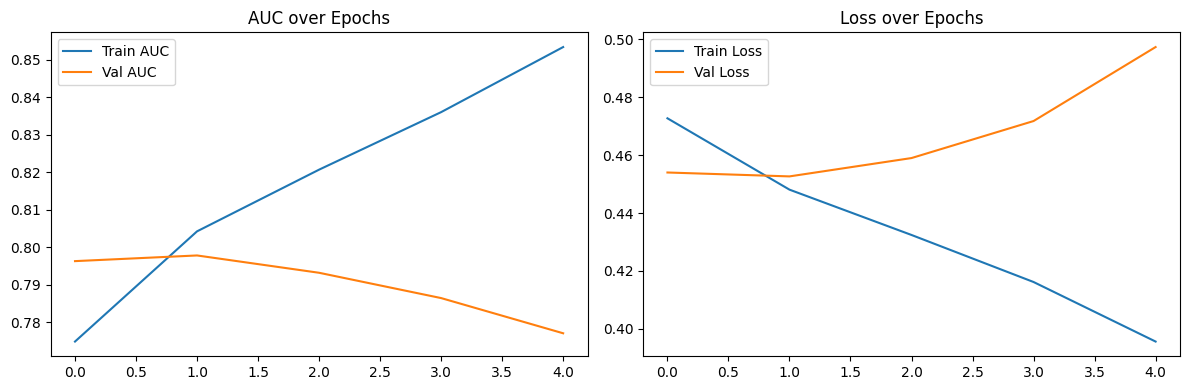

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['auc'], label='Train AUC')
axes[0].plot(history.history['val_auc'], label='Val AUC')
axes[0].set_title('AUC over Epochs')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].legend()

plt.tight_layout()
plt.show()


In [17]:
# Predict CTR probability for test samples
predictions = model.predict(test_inputs, batch_size=4096)

# predictions[i] = probability of click for sample i
print("Sample CTR predictions:", predictions[:10].flatten())

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step
Sample CTR predictions: [0.38661447 0.49750093 0.54445744 0.1001398  0.81973165 0.63919723
 0.01913435 0.0650136  0.77537453 0.03119103]
